**Analisis Exploratory Data Analysis (EDA) pada Dataset Customer Churn Telekomunikasi**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/telco_churn_cleaned.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Cek Struktur Data

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


Histogram (Distribusi Data)

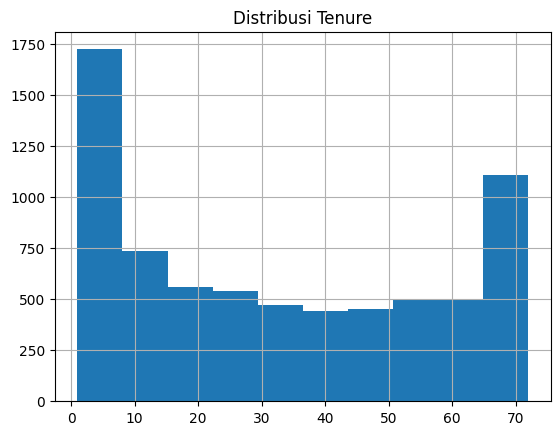

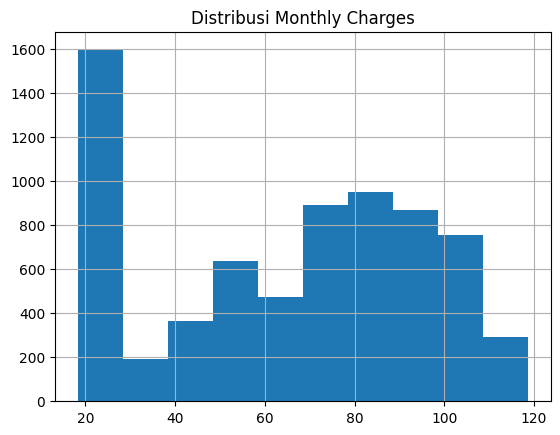

In [9]:
import matplotlib.pyplot as plt

df['tenure'].hist()
plt.title('Distribusi Tenure')
plt.show()

df['MonthlyCharges'].hist()
plt.title('Distribusi Monthly Charges')
plt.show()

Boxplot (Perbandingan Churn)

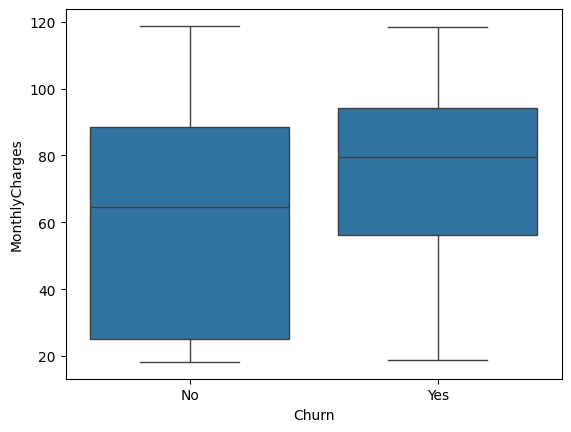

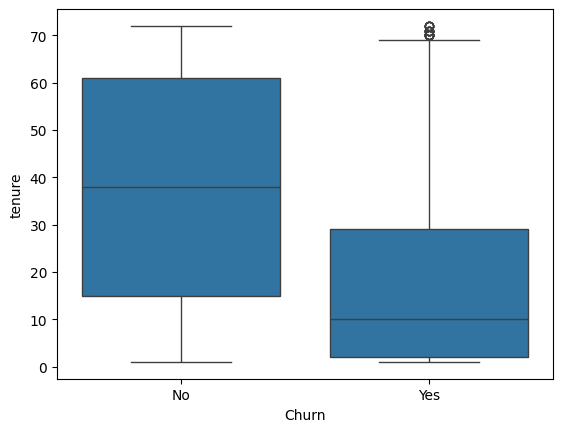

In [ ]:
import seaborn as sns

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

Heatmat (Korelasi) Awal

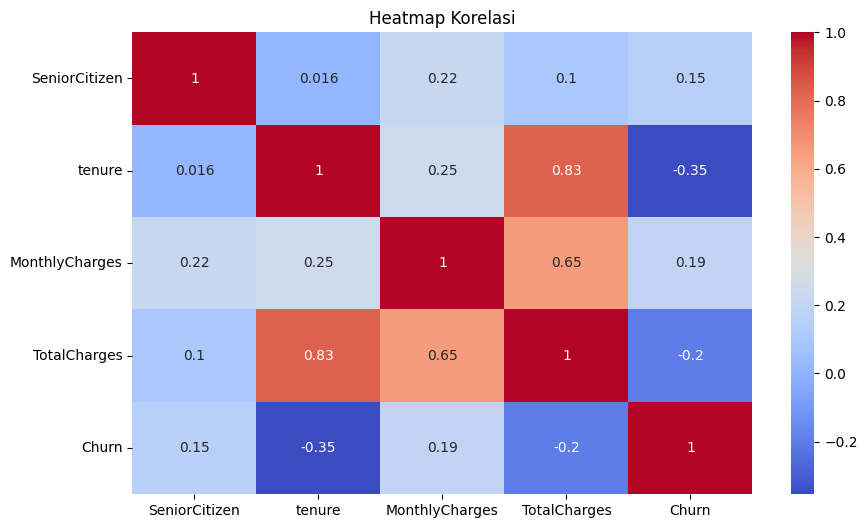

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil hanya kolom numerik
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Hitung korelasi
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

Heatman dengan Churn

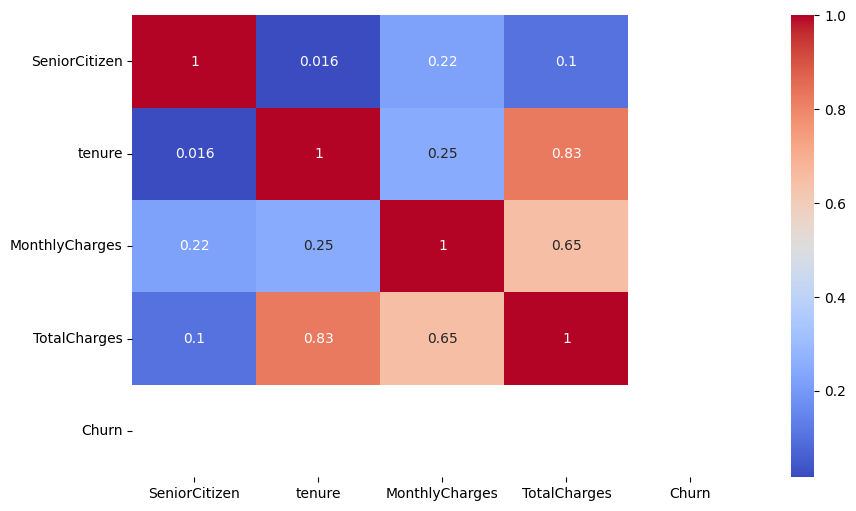

,Churn
SeniorCitizen,NaN
tenure,NaN
MonthlyCharges,NaN
TotalCharges,NaN
Churn,NaN


In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

corr['Churn'].sort_values(ascending=False)

**Hasil Analisis Exploratory Data Analysis (EDA)**

Berdasarkan hasil Exploratory Data Analysis (EDA) yang telah dilakukan, terlihat bahwa distribusi data pelanggan cukup beragam, terutama pada fitur lama berlangganan (tenure) dan biaya bulanan (MonthlyCharges). Visualisasi boxplot menunjukkan adanya perbedaan antara pelanggan yang melakukan churn dan yang tidak, dimana pelanggan dengan masa berlangganan lebih rendah cenderung lebih banyak melakukan churn. Selain itu, pelanggan dengan biaya bulanan yang lebih tinggi juga menunjukkan kecenderungan churn yang lebih besar.

Hasil analisis korelasi menunjukkan bahwa fitur tenure memiliki hubungan negatif terhadap churn, yang berarti semakin lama pelanggan berlangganan maka kemungkinan churn semakin kecil. Sebaliknya, fitur MonthlyCharges dan SeniorCitizen memiliki hubungan positif terhadap churn, meskipun tidak terlalu kuat. Hal ini menunjukkan bahwa faktor durasi berlangganan dan biaya layanan menjadi indikator penting dalam perilaku pelanggan.

Secara keseluruhan, dapat disimpulkan bahwa pelanggan dengan masa berlangganan yang singkat dan biaya bulanan yang tinggi memiliki risiko churn yang lebih besar. Oleh karena itu, perusahaan dapat memanfaatkan informasi ini untuk menyusun strategi retensi pelanggan yang lebih efektif, seperti memberikan promo atau peningkatan layanan kepada pelanggan yang berpotensi churn.